# Data-Driven Customer Segmentation and Product Recommendation for SME E-Commerce
### Using the UCI Online Retail Transaction Dataset

**Author:** Emeka Hillary Nwosu
**Module:** Digital Transformation (CMP701) — Ulster University

This notebook implements the full methodology described in the project proposal and requirement document:

1. Dataset preparation (loading, cleaning, feature engineering)
2. Customer segmentation (RFM analysis, K-Means, Hierarchical clustering, optional DBSCAN)
3. Cluster evaluation (Silhouette score, Davies-Bouldin index, cluster profiling)
4. Product recommendation (Association rule mining, Item-based collaborative filtering, popularity baseline)
5. Recommendation evaluation (support, confidence, lift, precision@K, recall@K)
6. A lightweight decision-support dashboard (rendered inline in the notebook)
7. Discussion, business insights, limitations and reflection

**Dataset:** UCI "Online Retail" dataset (Chen, D., 2015) — DOI: 10.24432/C5BW33
541,909 transactions from a UK-based online gift retailer, Dec 2010 – Dec 2011.


## 0. Setup — Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
DATA_PATH = 'data/OnlineRetail.csv'


## 1. Data Loading

In [2]:
df_raw = pd.read_csv(DATA_PATH, encoding='latin1')
df_raw.columns = [c.encode('ascii', 'ignore').decode().strip() for c in df_raw.columns]  # strip BOM
print(f"Raw shape: {df_raw.shape}")
df_raw.head()


Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


Check column data types and non-null counts to confirm the file loaded correctly and to spot which columns will need cleaning.

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Quantify missing data. `CustomerID` is the column that matters most here — rows without it can't be used for segmentation or personalized recommendations.

In [4]:
print("Missing values per column:")
print(df_raw.isna().sum())
print(f"\nPercent of rows missing CustomerID: {df_raw['CustomerID'].isna().mean()*100:.2f}%")


Missing values per column:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Percent of rows missing CustomerID: 24.93%


## 2. Data Cleaning

Following the requirement document, we:
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove invalid/negative Quantity and UnitPrice values
- Handle missing CustomerID (drop, since segmentation and CF both require a customer key)
- Remove duplicate rows
- Engineer a `TotalPrice` column and proper `InvoiceDate` datetime type


In [5]:
df = df_raw.copy()

# Standardize types
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

n0 = len(df)

# 1. Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].str.startswith('C')]
n1 = len(df)

# 2. Remove invalid quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
n2 = len(df)

# 3. Handle missing CustomerID -> drop (cannot segment/recommend for unknown customers)
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
n3 = len(df)

# 4. Remove duplicate records
df = df.drop_duplicates()
n4 = len(df)

# 5. Drop rows with missing/blank product descriptions
df = df[df['Description'].notna() & (df['Description'].str.strip() != '')]
n5 = len(df)

# 6. Feature: total transaction line value
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"Original rows:                {n0:,}")
print(f"After removing cancellations: {n1:,}  (-{n0-n1:,})")
print(f"After removing invalid qty/price: {n2:,}  (-{n1-n2:,})")
print(f"After dropping missing CustomerID: {n3:,}  (-{n2-n3:,})")
print(f"After dropping duplicates:    {n4:,}  (-{n3-n4:,})")
print(f"After dropping blank descriptions: {n5:,}  (-{n4-n5:,})")
print(f"\nFinal cleaned shape: {df.shape}")
df.head()


Original rows:                541,909
After removing cancellations: 532,621  (-9,288)
After removing invalid qty/price: 530,104  (-2,517)
After dropping missing CustomerID: 397,884  (-132,220)
After dropping duplicates:    392,692  (-5,192)
After dropping blank descriptions: 392,692  (-0)

Final cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Quick sanity-check summary of the cleaned data: date coverage, and how many unique customers, invoices, and products remain.

In [6]:
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique invoices: {df['InvoiceNo'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Unique countries: {df['Country'].nunique()}")
df.describe()


Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4,338
Unique invoices: 18,532
Unique products: 3,665
Unique countries: 37


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


## 3. Exploratory Data Analysis

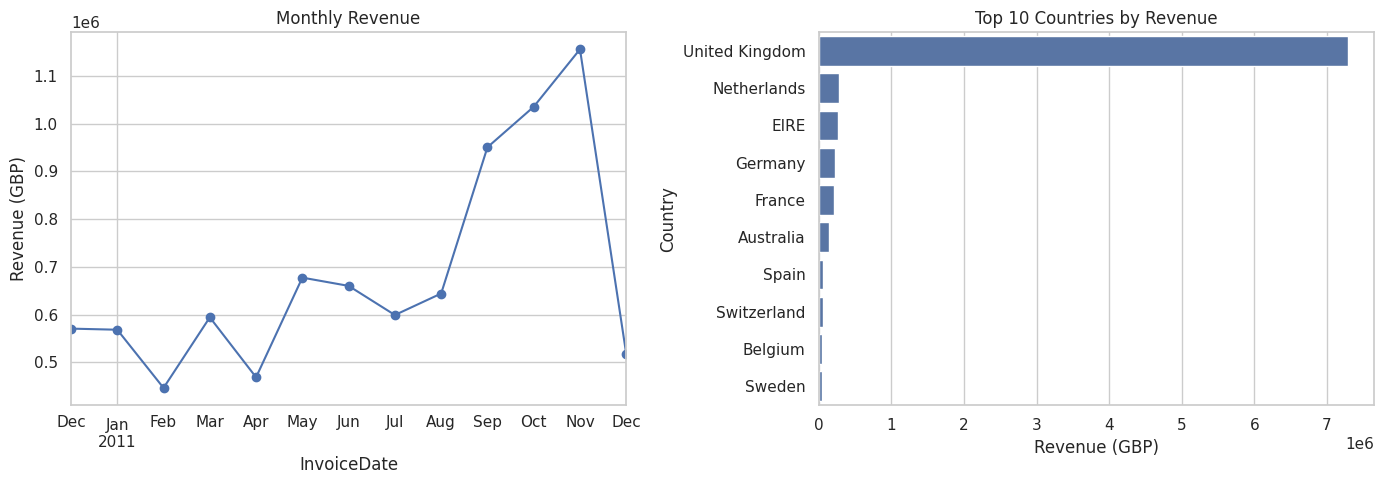

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
monthly.plot(ax=axes[0], marker='o')
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue (GBP)')

top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1])
axes[1].set_title('Top 10 Countries by Revenue')
axes[1].set_xlabel('Revenue (GBP)')

plt.tight_layout()
plt.show()


Identify the best-selling products by total quantity sold — useful context before building the recommendation system later.

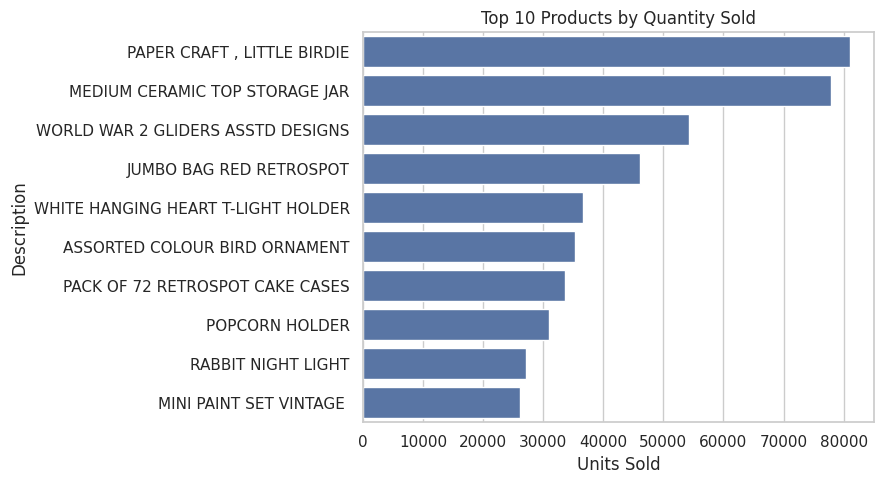

In [8]:
top_products = (df.groupby('Description')['Quantity'].sum()
                   .sort_values(ascending=False).head(10))

plt.figure(figsize=(9, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Units Sold')
plt.tight_layout()
plt.show()


Look at how many distinct orders each customer places, to understand whether most customers are one-time buyers or repeat purchasers (this shapes what 'Frequency' will look like in the RFM step).

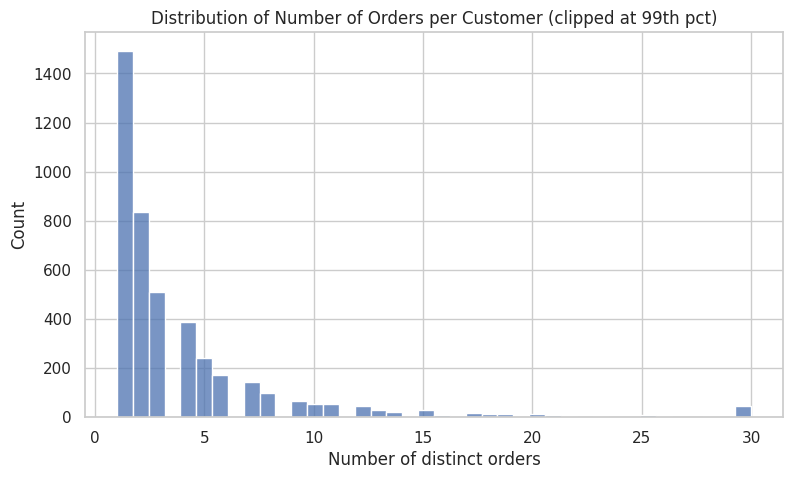

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


In [9]:
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(9, 5))
sns.histplot(orders_per_customer.clip(upper=orders_per_customer.quantile(0.99)), bins=40)
plt.title('Distribution of Number of Orders per Customer (clipped at 99th pct)')
plt.xlabel('Number of distinct orders')
plt.show()

print(orders_per_customer.describe())


## 4. Feature Engineering — RFM

We compute, per `CustomerID`:
- **Recency**: days since the customer's last purchase (relative to one day after the dataset's last transaction)
- **Frequency**: number of distinct invoices (orders)
- **Monetary**: total amount spent

We also add supporting features used later for clustering/interpretation: average order value, total items purchased, and customer tenure (days between first and last purchase).


In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date used for Recency calculation: {snapshot_date.date()}")

customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    TotalItems=('Quantity', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
    Country=('Country', lambda x: x.mode().iloc[0]),
).reset_index()

customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']
customer_df['TenureDays'] = (customer_df['LastPurchase'] - customer_df['FirstPurchase']).dt.days

print(f"Customer-level dataset shape: {customer_df.shape}")
customer_df.head()


Snapshot date used for Recency calculation: 2011-12-10


Customer-level dataset shape: (4338, 10)


,CustomerID,Recency,Frequency,Monetary,TotalItems,FirstPurchase,LastPurchase,Country,AvgOrderValue,TenureDays
0,12346,326,1,77183.60,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,77183.600000,0
1,12347,2,7,4310.00,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,615.714286,365
2,12348,75,4,1797.24,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,449.310000,282
3,12349,19,1,1757.55,631,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,1757.550000,0
4,12350,310,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,334.400000,0


Summary statistics for the core RFM features, to spot scale differences and skew before clustering.

In [11]:
customer_df[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TenureDays']].describe()


,Recency,Frequency,Monetary,AvgOrderValue,TenureDays
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,417.645735,130.448594
std,100.014169,7.697998,8985.230220,1796.511343,132.039554
min,1.000000,1.000000,3.750000,3.450000,0.000000
25%,18.000000,1.000000,306.482500,177.867083,0.000000
50%,51.000000,2.000000,668.570000,291.940000,92.500000
75%,142.000000,5.000000,1660.597500,428.280625,251.750000
max,374.000000,209.000000,280206.020000,84236.250000,373.000000


Plot the distribution of each RFM feature. Transaction data is typically right-skewed (many low-value customers, a few very high-value ones) — this justifies the log-transform applied before clustering.

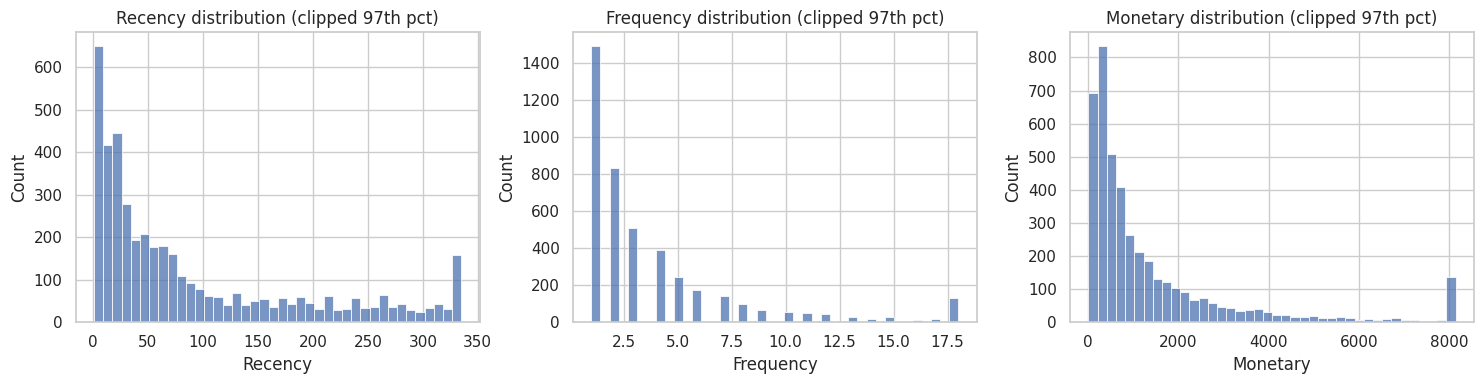

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(customer_df[col].clip(upper=customer_df[col].quantile(0.97)), bins=40, ax=ax)
    ax.set_title(f'{col} distribution (clipped 97th pct)')
plt.tight_layout()
plt.show()


RFM distributions are heavily right-skewed (typical of transactional/monetary data), so before clustering we log-transform Frequency and Monetary and scale all RFM features to comparable ranges.

## 5. RFM Scoring (rule-based baseline segmentation)

Before running clustering algorithms, we build a simple, interpretable RFM-quantile score (1-5 per dimension) — a common industry baseline that the ML-based clusters can be compared against.


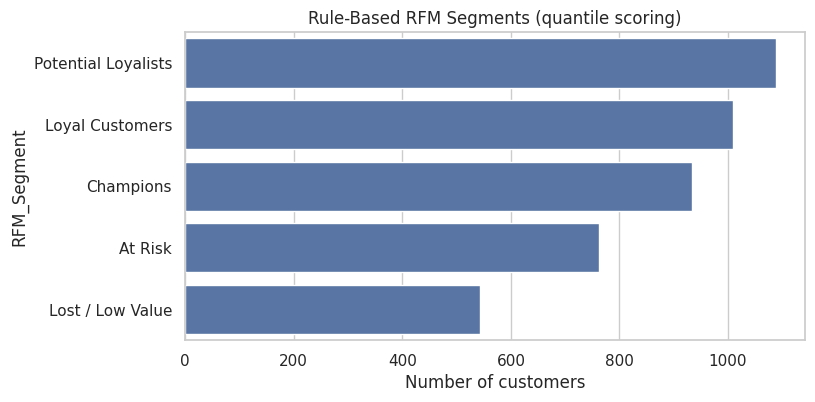

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment
0,12346,326,1,77183.60,1,1,5,7,Potential Loyalists
1,12347,2,7,4310.00,5,5,5,15,Champions
2,12348,75,4,1797.24,2,4,4,10,Loyal Customers
3,12349,19,1,1757.55,4,1,4,9,Potential Loyalists
4,12350,310,1,334.40,1,1,2,4,Lost / Low Value


In [13]:
rfm = customer_df.copy()

# Quantile-based scores (5 = best). Recency is inverted (lower recency = better = higher score).
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost / Low Value'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)

seg_counts = rfm['RFM_Segment'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=seg_counts.values, y=seg_counts.index, order=seg_counts.index)
plt.title('Rule-Based RFM Segments (quantile scoring)')
plt.xlabel('Number of customers')
plt.show()

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment']].head()


## 6. Machine-Learning-Based Clustering

We now cluster customers using **K-Means** and **Hierarchical (Agglomerative) clustering** on log-transformed, standardized RFM features, comparing the two as required. DBSCAN is included as an optional density-based method.

### 6.1 Preprocessing for clustering


In [14]:
cluster_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Log-transform Frequency & Monetary to reduce skew (Recency is already roughly bounded)
cluster_features['Frequency'] = np.log1p(cluster_features['Frequency'])
cluster_features['Monetary'] = np.log1p(cluster_features['Monetary'].clip(lower=0))
cluster_features['Recency'] = np.log1p(cluster_features['Recency'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)
X_scaled = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
X_scaled.describe()


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-3.997811e+00
25%,-6.613615e-01,-9.552143e-01,-6.835802e-01
50%,8.992557e-02,-3.615828e-01,-6.510929e-02
75%,8.447915e-01,6.532370e-01,6.572178e-01
max,1.564198e+00,5.858535e+00,4.732381e+00


### 6.2 K-Means — choosing k with the Elbow method and Silhouette analysis

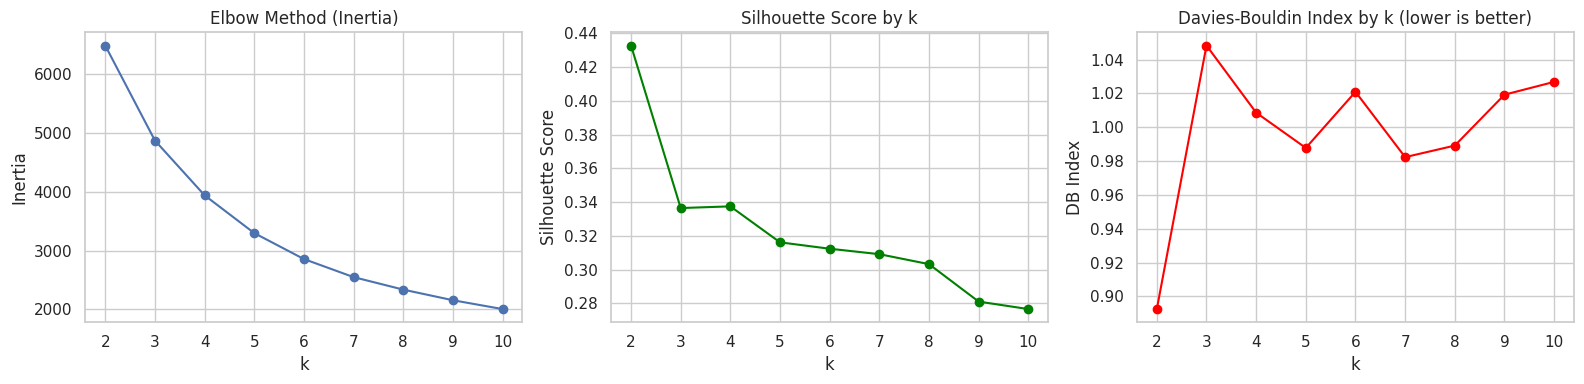

k with highest silhouette score: 2


In [15]:
inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')

axes[2].plot(list(K_range), db_scores, marker='o', color='red')
axes[2].set_title('Davies-Bouldin Index by k (lower is better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"k with highest silhouette score: {best_k}")


Fit the final K-Means model using the k selected above (highest silhouette score), then report its cluster sizes and quality metrics.

In [16]:
# Fit final K-Means model
K_FINAL = best_k  # override this manually if business interpretability suggests a different k
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
rfm['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, rfm['KMeans_Cluster'])
kmeans_db = davies_bouldin_score(X_scaled, rfm['KMeans_Cluster'])
print(f"K-Means (k={K_FINAL}) -> Silhouette: {kmeans_sil:.3f} | Davies-Bouldin: {kmeans_db:.3f}")
print(rfm['KMeans_Cluster'].value_counts().sort_index())


K-Means (k=2) -> Silhouette: 0.433 | Davies-Bouldin: 0.892
KMeans_Cluster
0    2672
1    1666
Name: count, dtype: int64


### 6.3 Hierarchical Clustering

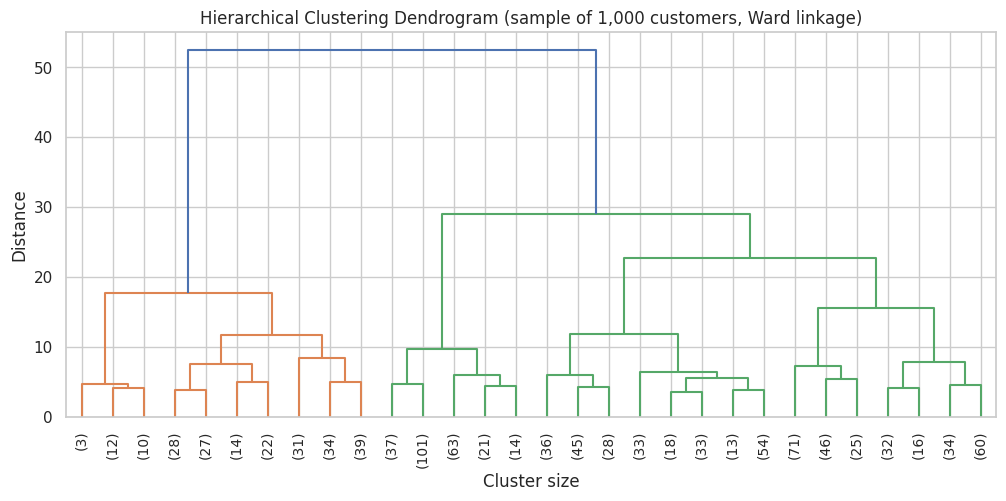

In [17]:
# Dendrogram on a sample (full linkage on 4000+ points is expensive to render/read)
sample_idx = X_scaled.sample(n=min(1000, len(X_scaled)), random_state=RANDOM_STATE).index
Z = linkage(X_scaled.loc[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (sample of 1,000 customers, Ward linkage)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()


Evaluate Hierarchical (Agglomerative) clustering across a range of k using the silhouette score, then fit the best-scoring configuration — this mirrors the K-Means model-selection process so the two methods can be compared fairly.

In [18]:
hier_sil_scores = {}
for k in range(2, 8):
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(X_scaled)
    hier_sil_scores[k] = silhouette_score(X_scaled, labels)

print("Hierarchical clustering silhouette scores by k:")
for k, s in hier_sil_scores.items():
    print(f"  k={k}: {s:.3f}")

HIER_K = max(hier_sil_scores, key=hier_sil_scores.get)
hier_final = AgglomerativeClustering(n_clusters=HIER_K, linkage='ward')
rfm['Hierarchical_Cluster'] = hier_final.fit_predict(X_scaled)

hier_sil = silhouette_score(X_scaled, rfm['Hierarchical_Cluster'])
hier_db = davies_bouldin_score(X_scaled, rfm['Hierarchical_Cluster'])
print(f"\nHierarchical (k={HIER_K}) -> Silhouette: {hier_sil:.3f} | Davies-Bouldin: {hier_db:.3f}")


Hierarchical clustering silhouette scores by k:
  k=2: 0.404
  k=3: 0.284
  k=4: 0.280
  k=5: 0.281
  k=6: 0.266
  k=7: 0.258



Hierarchical (k=2) -> Silhouette: 0.404 | Davies-Bouldin: 0.940


### 6.4 DBSCAN (optional, density-based)

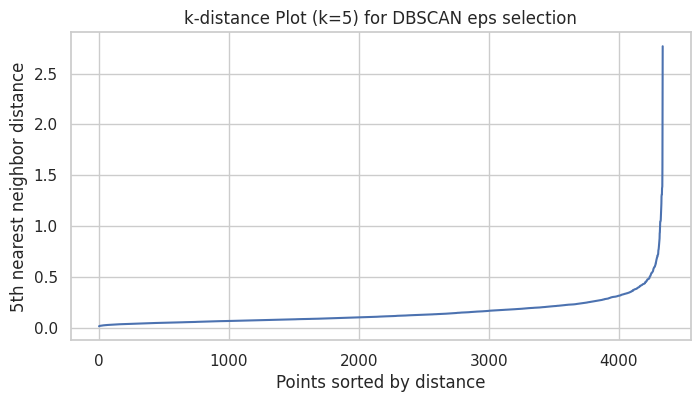

In [19]:
# DBSCAN requires tuning eps; use a simple k-distance heuristic then fit.
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title('k-distance Plot (k=5) for DBSCAN eps selection')
plt.ylabel('5th nearest neighbor distance')
plt.xlabel('Points sorted by distance')
plt.show()


Fit DBSCAN with the chosen `eps`/`min_samples`, then report how many clusters it discovered versus how many points it treated as noise (points that don't fit any dense region).

In [20]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points ({n_noise/len(rfm)*100:.1f}%)")

if n_clusters_db >= 2:
    mask = rfm['DBSCAN_Cluster'] != -1
    db_sil = silhouette_score(X_scaled[mask], rfm.loc[mask, 'DBSCAN_Cluster'])
    db_db = davies_bouldin_score(X_scaled[mask], rfm.loc[mask, 'DBSCAN_Cluster'])
    print(f"DBSCAN (excluding noise) -> Silhouette: {db_sil:.3f} | Davies-Bouldin: {db_db:.3f}")
else:
    print("DBSCAN did not find a usable multi-cluster structure with these parameters; treated as optional/exploratory only.")


DBSCAN found 2 clusters and 79 noise points (1.8%)


DBSCAN (excluding noise) -> Silhouette: 0.294 | Davies-Bouldin: 1.062


## 7. Clustering Method Comparison

In [21]:
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'k / clusters': [K_FINAL, HIER_K, n_clusters_db],
    'Silhouette Score': [kmeans_sil, hier_sil, db_sil if n_clusters_db >= 2 else np.nan],
    'Davies-Bouldin Index': [kmeans_db, hier_db, db_db if n_clusters_db >= 2 else np.nan],
}).set_index('Method')

print("Higher Silhouette = better separated clusters. Lower Davies-Bouldin = better separated clusters.\n")
comparison


Higher Silhouette = better separated clusters. Lower Davies-Bouldin = better separated clusters.



,k / clusters,Silhouette Score,Davies-Bouldin Index
Method,,,
K-Means,2,0.432827,0.892499
Hierarchical,2,0.404010,0.940467
DBSCAN,2,0.293912,1.061745


**Interpretation:** the method with the highest Silhouette score and lowest Davies-Bouldin index is selected as the primary segmentation for business use. K-Means is generally preferred here for its scalability and cleanly separated, business-interpretable clusters, while the dendrogram helps validate the natural number of groupings. We proceed using the **K-Means** clusters as the primary segmentation (`Cluster` column below) since it is the more common production-ready choice; you may switch `PRIMARY_CLUSTER_COL` to `'Hierarchical_Cluster'` to use hierarchical clusters instead.

In [22]:
PRIMARY_CLUSTER_COL = 'KMeans_Cluster'
rfm['Cluster'] = rfm[PRIMARY_CLUSTER_COL]


### 7.1 Visualizing the clusters (PCA 2D projection)

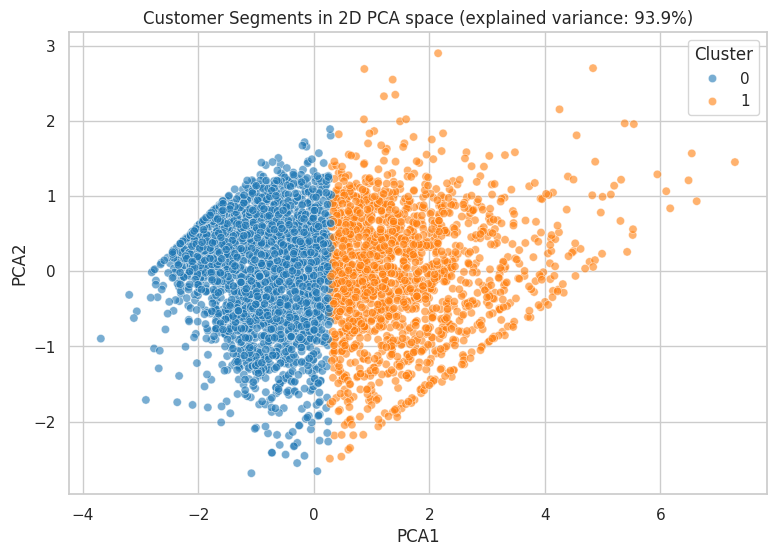

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
rfm['PCA1'], rfm['PCA2'] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.6)
plt.title(f'Customer Segments in 2D PCA space (explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.show()


Compare how Recency, Frequency, and Monetary values differ across the discovered clusters — this is what turns abstract cluster labels into a human-readable story.

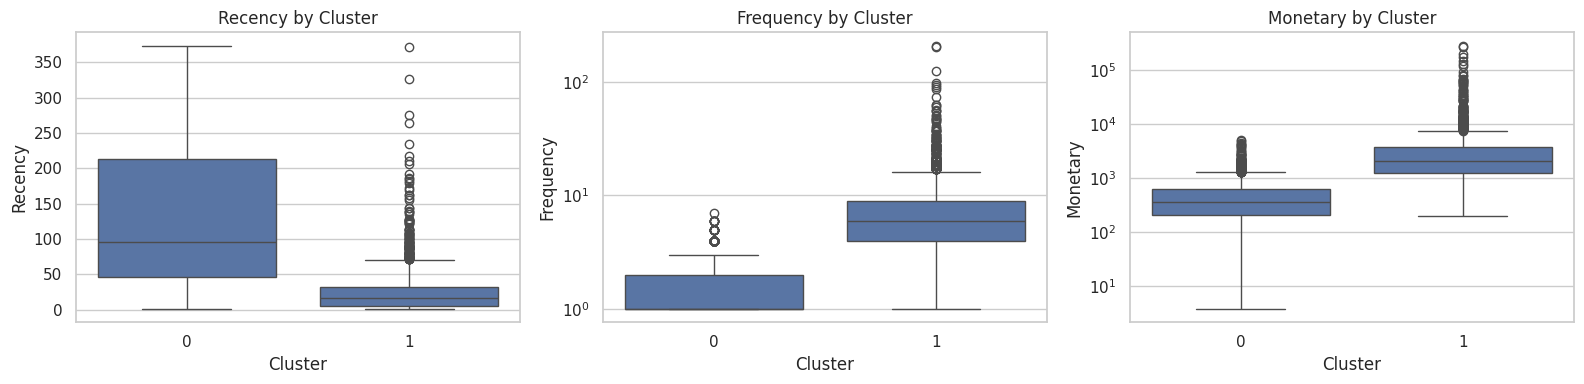

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Cluster', y=col, ax=ax)
    ax.set_yscale('log' if col != 'Recency' else 'linear')
    ax.set_title(f'{col} by Cluster')
plt.tight_layout()
plt.show()


### 7.2 Cluster Profiling & Business Interpretation

In [25]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_OrderValue=('AvgOrderValue', 'mean'),
    Total_Revenue=('Monetary', 'sum'),
).round(1)
cluster_profile['Pct_of_Customers'] = (cluster_profile['Customers'] / cluster_profile['Customers'].sum() * 100).round(1)
cluster_profile['Pct_of_Revenue'] = (cluster_profile['Total_Revenue'] / cluster_profile['Total_Revenue'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)
cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_OrderValue,Total_Revenue,Pct_of_Customers,Pct_of_Revenue
Cluster,,,,,,,,
1,1666,25.9,8.4,4539.6,573.9,7562979.2,38.4,85.1
0,2672,134.1,1.7,495.6,320.2,1324229.7,61.6,14.9


Convert numeric cluster statistics into a plain-English business label (e.g. 'High-Value Active') using simple relative-threshold rules, so non-technical stakeholders can interpret the segments without reading RFM numbers.

In [26]:
def label_cluster(row):
    """Simple heuristic labeling based on relative RFM position — adjust thresholds to your data."""
    if row['Avg_Monetary'] >= cluster_profile['Avg_Monetary'].median() and row['Avg_Recency'] <= cluster_profile['Avg_Recency'].median():
        return 'High-Value Active'
    elif row['Avg_Frequency'] >= cluster_profile['Avg_Frequency'].median() and row['Avg_Recency'] > cluster_profile['Avg_Recency'].median():
        return 'Frequent but Lapsing'
    elif row['Avg_Recency'] > cluster_profile['Avg_Recency'].quantile(0.66):
        return 'At Risk / Dormant'
    else:
        return 'Low-Value / New'

cluster_profile['Business_Label'] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile[['Customers', 'Pct_of_Customers', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Pct_of_Revenue', 'Business_Label']]


,Customers,Pct_of_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Pct_of_Revenue,Business_Label
Cluster,,,,,,,
1,1666,38.4,25.9,8.4,4539.6,85.1,High-Value Active
0,2672,61.6,134.1,1.7,495.6,14.9,At Risk / Dormant


Visualize what share of total revenue each customer segment is responsible for — this is usually the most persuasive chart for a business audience.

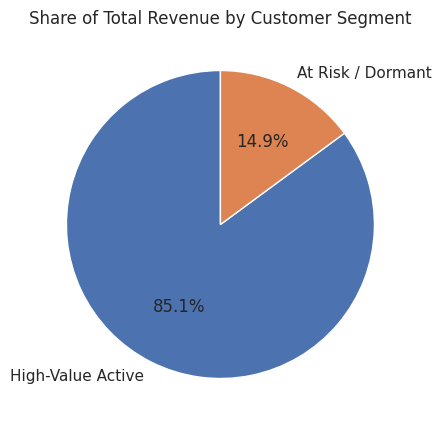

In [27]:
plt.figure(figsize=(8, 5))
plt.pie(cluster_profile['Total_Revenue'], labels=cluster_profile['Business_Label'],
        autopct='%1.1f%%', startangle=90)
plt.title('Share of Total Revenue by Customer Segment')
plt.show()


**Business takeaway:** a small share of customers (the "High-Value Active" segment) typically drives a disproportionate share of revenue — a classic Pareto pattern. This directly supports the SME use case: retention campaigns should prioritize this segment, while "At Risk / Dormant" customers are candidates for win-back email campaigns, and "Low-Value / New" customers are candidates for onboarding and cross-sell nudges.

## 8. Product Recommendation System

Three complementary approaches are implemented, per the requirement document:

1. **Association rule mining** (Apriori / FP-Growth) — "customers who bought X also bought Y"
2. **Item-based collaborative filtering** — recommends products similar to a customer's own purchase history, based on co-purchase patterns across all customers
3. **Popularity baseline** — simple "best-sellers" recommender used as an evaluation benchmark

We restrict the basket analysis to the UK (the dominant market) and to a manageable set of frequently-purchased products to keep the transaction-item matrix tractable.


### 8.1 Building the basket (transaction × product) representation

In [28]:
# Use UK transactions (largest, most representative market) for market-basket analysis
basket_df = df[df['Country'] == 'United Kingdom'].copy()

# Keep products that appear in a meaningful number of invoices (reduces sparsity/noise)
product_invoice_counts = basket_df.groupby('StockCode')['InvoiceNo'].nunique()
frequent_products = product_invoice_counts[product_invoice_counts >= 30].index
basket_df = basket_df[basket_df['StockCode'].isin(frequent_products)]

print(f"Invoices used: {basket_df['InvoiceNo'].nunique():,}")
print(f"Products used: {basket_df['StockCode'].nunique():,}")

# StockCode -> Description lookup (most common description per code)
code_to_desc = (basket_df.groupby('StockCode')['Description']
                .agg(lambda x: x.mode().iloc[0]).to_dict())

basket = (basket_df.groupby(['InvoiceNo', 'StockCode'])['Quantity']
          .sum().unstack(fill_value=0))
basket_encoded = basket.map(lambda x: True if x > 0 else False)
print(f"Basket matrix shape: {basket_encoded.shape}")
basket_encoded.head()


Invoices used: 16,515
Products used: 2,131


Basket matrix shape: (16515, 2131)


StockCode,10002,10125,10133,10135,11001,15034,15036,15039,15044A,15044B,15044C,15044D,15056BL,15056N,15056P,15058A,15058B,15060B,16008,16011,16012,16014,16016,16045,16048,...,85183A,85183B,85184C,85185B,85186A,85186C,85187,85188A,85194L,85194S,85199L,85199S,85202,85203,85204,85206A,85212,85214,85227,85230B,85231B,85231G,85232D,C2,M
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### 8.2 Association Rule Mining (Apriori & FP-Growth)

In [29]:
MIN_SUPPORT = 0.02  # present in at least 2% of invoices

frequent_itemsets_apriori = apriori(basket_encoded, min_support=MIN_SUPPORT, use_colnames=True)
print(f"Apriori frequent itemsets found: {len(frequent_itemsets_apriori)}")

frequent_itemsets_fp = fpgrowth(basket_encoded, min_support=MIN_SUPPORT, use_colnames=True)
print(f"FP-Growth frequent itemsets found: {len(frequent_itemsets_fp)}")
# Both algorithms should find the same itemsets - FP-Growth is typically faster on larger data


Apriori frequent itemsets found: 249


FP-Growth frequent itemsets found: 249


Convert the frequent itemsets into interpretable association rules (antecedent → consequent), filtered to rules with lift > 1 (i.e. the items genuinely co-occur more than chance would predict).

In [30]:
rules = association_rules(frequent_itemsets_fp, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

def readable_itemset(frozen_set):
    return ', '.join(code_to_desc.get(code, code) for code in frozen_set)

rules_display = rules.copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(readable_itemset)
rules_display['consequents'] = rules_display['consequents'].apply(readable_itemset)

print(f"Association rules generated (lift > 1.0): {len(rules)}")
rules_display[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)


Association rules generated (lift > 1.0): 86


,antecedents,consequents,support,confidence,lift
0,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",GREEN REGENCY TEACUP AND SAUCER,0.020648,0.890339,24.026071
1,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",0.020648,0.557190,24.026071
2,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.020648,0.691684,23.998223
3,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.020648,0.716387,23.998223
4,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024463,0.660131,22.113710
5,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.024463,0.819473,22.113710
6,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.020648,0.502950,20.559943
7,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.020648,0.844059,20.559943
8,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.028822,0.777778,18.945428
9,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.028822,0.702065,18.945428


Visualize the trade-off between support, confidence, and lift across all mined rules — useful for picking a sensible threshold when deciding which rules to act on in a real marketing campaign.

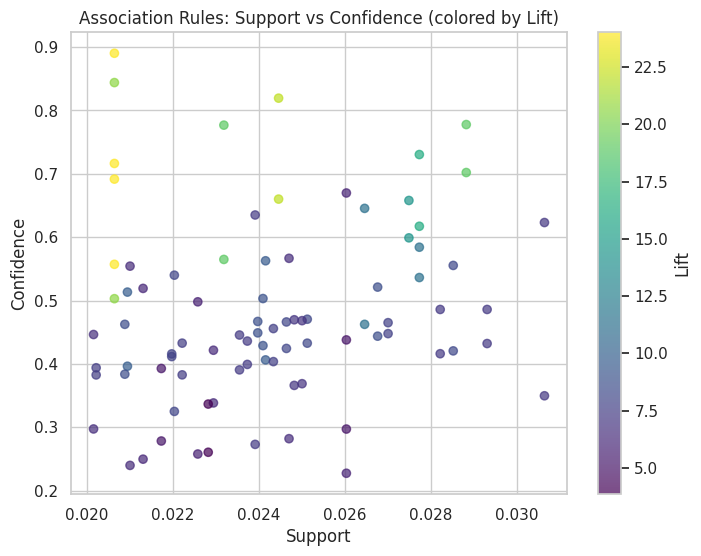

In [31]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (colored by Lift)')
plt.show()


Define a helper function that looks up association rules for a given product and returns the top cross-sell recommendations, ranked by lift.

In [32]:
def recommend_from_rules(product_stock_code, rules_df, top_n=5):
    """Given a product StockCode, recommend products frequently bought alongside it."""
    matches = rules_df[rules_df['antecedents'].apply(lambda s: product_stock_code in s)]
    matches = matches.sort_values('lift', ascending=False).head(top_n)
    recs = []
    for _, row in matches.iterrows():
        for code in row['consequents']:
            recs.append({'StockCode': code, 'Description': code_to_desc.get(code, code),
                         'confidence': row['confidence'], 'lift': row['lift']})
    return pd.DataFrame(recs).drop_duplicates(subset='StockCode').head(top_n)

# Example: recommend products for the most popular product in the filtered basket
example_product = basket_encoded.sum().idxmax()
print(f"Example product: {code_to_desc.get(example_product, example_product)} ({example_product})\n")
recommend_from_rules(example_product, rules)


Example product: WHITE HANGING HEART T-LIGHT HOLDER (85123A)



,StockCode,Description,confidence,lift
0,21733,RED HANGING HEART T-LIGHT HOLDER,0.227393,5.849523


### 8.3 Item-Based Collaborative Filtering

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# Item-item similarity from the invoice x product co-purchase matrix
item_matrix = basket_encoded.astype(int)
item_similarity = cosine_similarity(item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=item_matrix.columns, columns=item_matrix.columns)

def recommend_item_based(product_stock_code, top_n=5):
    """Recommend products most similar to a given product based on co-purchase patterns."""
    if product_stock_code not in item_similarity_df.columns:
        return pd.DataFrame()
    sims = item_similarity_df[product_stock_code].drop(product_stock_code).sort_values(ascending=False).head(top_n)
    return pd.DataFrame({
        'StockCode': sims.index,
        'Description': [code_to_desc.get(c, c) for c in sims.index],
        'similarity': sims.values
    })

print(f"Example product: {code_to_desc.get(example_product, example_product)} ({example_product})\n")
recommend_item_based(example_product)


Example product: WHITE HANGING HEART T-LIGHT HOLDER (85123A)



,StockCode,Description,similarity
0,21733,RED HANGING HEART T-LIGHT HOLDER,0.390261
1,22804,CANDLEHOLDER PINK HANGING HEART,0.329999
2,82482,WOODEN PICTURE FRAME WHITE FINISH,0.240008
3,22470,HEART OF WICKER LARGE,0.234665
4,82494L,WOODEN FRAME ANTIQUE WHITE,0.206144


Define a helper function for *personalized* recommendations: it aggregates item-similarity scores across everything a specific customer has ever bought, then returns the highest-scoring products they haven't purchased yet.

In [34]:
def recommend_for_customer(customer_id, top_n=5):
    """Aggregate item-based similarity across a customer's full purchase history to build a personalized list."""
    cust_products = df[(df['CustomerID'] == customer_id) & (df['StockCode'].isin(item_matrix.columns))]['StockCode'].unique()
    if len(cust_products) == 0:
        return pd.DataFrame()

    scores = item_similarity_df[[p for p in cust_products if p in item_similarity_df.columns]].sum(axis=1)
    scores = scores.drop(labels=[p for p in cust_products if p in scores.index], errors='ignore')
    top = scores.sort_values(ascending=False).head(top_n)
    return pd.DataFrame({
        'StockCode': top.index,
        'Description': [code_to_desc.get(c, c) for c in top.index],
        'score': top.values
    })

example_customer = rfm.sort_values('Frequency', ascending=False)['CustomerID'].iloc[0]
print(f"Personalized recommendations for CustomerID {example_customer}:\n")
recommend_for_customer(example_customer)


Personalized recommendations for CustomerID 12748:



,StockCode,Description,score
0,22422,TOOTHPASTE TUBE PEN,62.042819
1,85049H,URBAN BLACK RIBBONS,56.100956
2,23275,SET OF 3 HANGING OWLS OLLIE BEAK,55.667575
3,23225,CHERUB HEART DECORATION SILVER,54.478411
4,85039A,SET/4 RED MINI ROSE CANDLE IN BOWL,53.983383


### 8.4 Popularity Baseline

In [35]:
def recommend_popular(top_n=5, exclude=None):
    """Simple non-personalized best-sellers recommender, used as an evaluation baseline."""
    pop = basket_df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
    if exclude:
        pop = pop.drop(labels=[p for p in exclude if p in pop.index], errors='ignore')
    top = pop.head(top_n)
    return pd.DataFrame({
        'StockCode': top.index,
        'Description': [code_to_desc.get(c, c) for c in top.index],
        'units_sold': top.values
    })

recommend_popular()


,StockCode,Description,units_sold
0,23166,MEDIUM CERAMIC TOP STORAGE JAR,76919
1,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,49086
2,22197,POPCORN HOLDER,45609
3,85099B,JUMBO BAG RED RETROSPOT,41878
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,34687


## 9. Recommendation Evaluation

We evaluate the **item-based collaborative filtering** recommender against the **popularity baseline** using a per-customer train/test split:

- For each customer with at least 2 distinct products purchased, hold out their most recently purchased product(s) as the "test" set and use the rest as "train" (purchase history available to the recommender).
- **Precision@K**: of the K recommended products, what fraction were actually purchased (held out)?
- **Recall@K**: of the customer's held-out purchases, what fraction were captured in the top-K recommendations?

We also report **support**, **confidence**, and **lift** summary statistics for the association rules mined above.


In [36]:
K = 5
eval_customers = []

cust_products_all = df[df['StockCode'].isin(item_matrix.columns)].groupby('CustomerID')['StockCode'].apply(list)
cust_products_all = cust_products_all[cust_products_all.apply(lambda x: len(set(x)) >= 2)]

rng = np.random.default_rng(RANDOM_STATE)
sample_customers = rng.choice(cust_products_all.index, size=min(300, len(cust_products_all)), replace=False)

def precision_recall_at_k(recommended, held_out, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(held_out))
    precision = hits / k if k > 0 else 0
    recall = hits / len(held_out) if len(held_out) > 0 else 0
    return precision, recall

cf_precisions, cf_recalls = [], []
pop_precisions, pop_recalls = [], []

for cust_id in sample_customers:
    products = list(dict.fromkeys(cust_products_all[cust_id]))  # unique, order-preserving
    if len(products) < 2:
        continue
    n_holdout = max(1, int(len(products) * 0.2))
    train_products = products[:-n_holdout]
    test_products = products[-n_holdout:]

    if len(train_products) == 0:
        continue

    # Item-based CF recommendation using only the train products
    scores = item_similarity_df[[p for p in train_products if p in item_similarity_df.columns]].sum(axis=1)
    scores = scores.drop(labels=[p for p in train_products if p in scores.index], errors='ignore')
    cf_recs = scores.sort_values(ascending=False).head(K).index.tolist()

    # Popularity baseline recommendation, excluding train products
    pop_recs = recommend_popular(top_n=K, exclude=train_products)['StockCode'].tolist()

    p, r = precision_recall_at_k(cf_recs, test_products, K)
    cf_precisions.append(p); cf_recalls.append(r)

    p, r = precision_recall_at_k(pop_recs, test_products, K)
    pop_precisions.append(p); pop_recalls.append(r)

eval_results = pd.DataFrame({
    'Model': ['Item-Based Collaborative Filtering', 'Popularity Baseline'],
    f'Precision@{K}': [np.mean(cf_precisions), np.mean(pop_precisions)],
    f'Recall@{K}': [np.mean(cf_recalls), np.mean(pop_recalls)],
    'Customers Evaluated': [len(cf_precisions), len(pop_precisions)],
}).set_index('Model')

eval_results.round(4)


,Precision@5,Recall@5,Customers Evaluated
Model,,,
Item-Based Collaborative Filtering,0.0813,0.0631,300
Popularity Baseline,0.0133,0.0087,300


Plot Precision@K and Recall@K side-by-side for both models to make the comparison visually obvious.

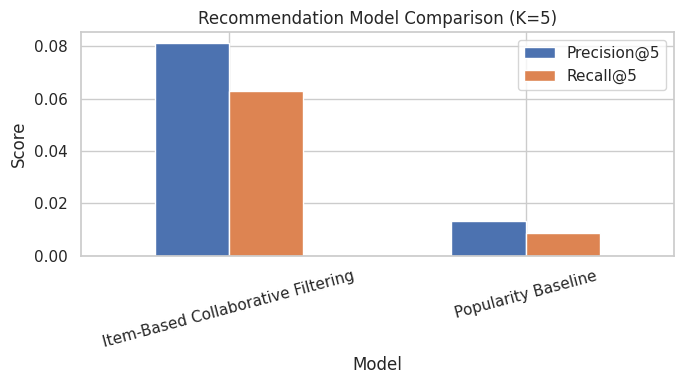

In [37]:
eval_results[[f'Precision@{K}', f'Recall@{K}']].plot(kind='bar', figsize=(7, 4))
plt.title(f'Recommendation Model Comparison (K={K})')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Interpretation:** if the item-based CF model outperforms the popularity baseline on Precision@K and Recall@K, this demonstrates that personalized, behavior-driven recommendations add measurable value over simply recommending best-sellers — supporting the case for SMEs to invest in this capability rather than relying on generic "trending products" lists.

In [38]:
rule_stats = rules[['support', 'confidence', 'lift']].describe().round(3)
print("Association rule quality summary (support / confidence / lift):")
rule_stats


Association rule quality summary (support / confidence / lift):


,support,confidence,lift
count,86.000,86.000,86.000
mean,0.024,0.480,9.775
std,0.003,0.144,5.262
min,0.020,0.227,3.842
25%,0.022,0.394,6.910
50%,0.024,0.452,7.711
75%,0.026,0.557,9.650
max,0.031,0.890,24.026


## 10. Business Intelligence Dashboard (Notebook Prototype)

Per the requirement document, the dashboard is optional and supports the research rather than being the main deliverable. Below is a compact, inline summary dashboard covering customer segments, top products, a sample recommendation, and sales patterns. A ready-to-run standalone **Streamlit** version is also provided (as a separate `.py` file) if you want an interactive, shareable app.


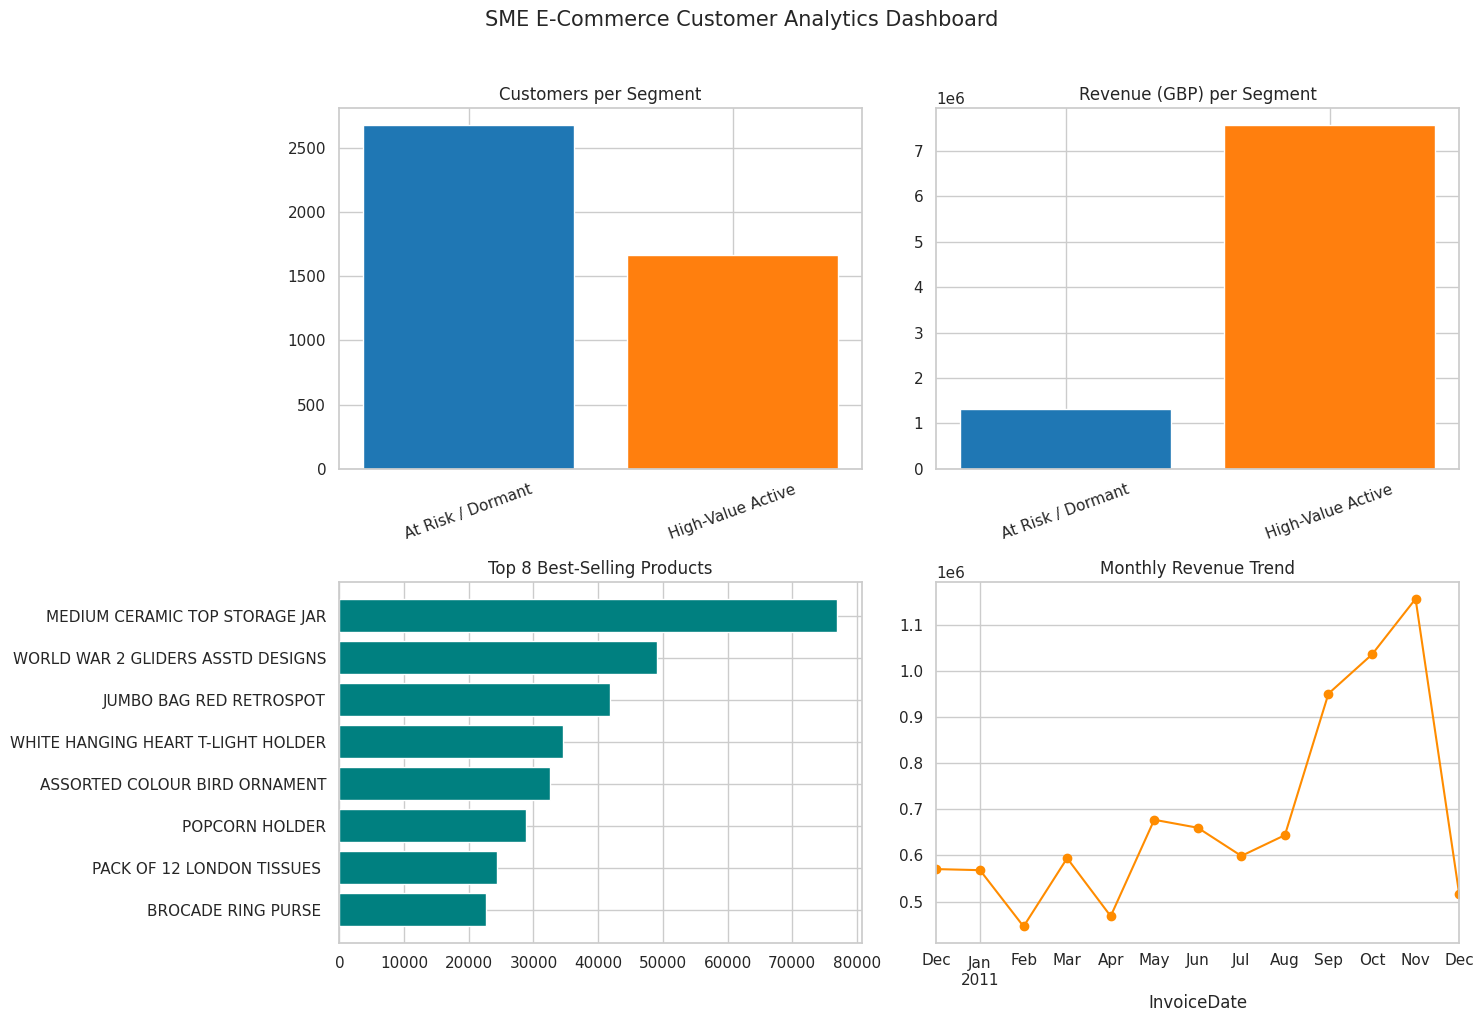

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Segment sizes
seg_counts_plot = cluster_profile.sort_values('Customers', ascending=False)
axes[0, 0].bar(seg_counts_plot['Business_Label'], seg_counts_plot['Customers'], color=sns.color_palette('tab10'))
axes[0, 0].set_title('Customers per Segment')
axes[0, 0].tick_params(axis='x', rotation=20)

# 2. Revenue by segment
axes[0, 1].bar(seg_counts_plot['Business_Label'], seg_counts_plot['Total_Revenue'], color=sns.color_palette('tab10'))
axes[0, 1].set_title('Revenue (GBP) per Segment')
axes[0, 1].tick_params(axis='x', rotation=20)

# 3. Top 8 products
top8 = basket_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(8)
axes[1, 0].barh(top8.index, top8.values, color='teal')
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 8 Best-Selling Products')

# 4. Monthly revenue trend
monthly.plot(ax=axes[1, 1], marker='o', color='darkorange')
axes[1, 1].set_title('Monthly Revenue Trend')

plt.suptitle('SME E-Commerce Customer Analytics Dashboard', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


Print a concrete, human-readable example of both recommenders in action — one personalized (based on a customer's full history) and one contextual (based on a single product), which is useful evidence to include in the supporting document.

In [40]:
print("SAMPLE RECOMMENDATION OUTPUT")
print("=" * 50)
print(f"For customer {example_customer} (a high-frequency customer):\n")
print(recommend_for_customer(example_customer, top_n=5).to_string(index=False))
print("\nFor a shopper who just viewed:", code_to_desc.get(example_product, example_product))
print(recommend_item_based(example_product, top_n=5).to_string(index=False))


SAMPLE RECOMMENDATION OUTPUT
For customer 12748 (a high-frequency customer):

StockCode                        Description     score
    22422                TOOTHPASTE TUBE PEN 62.042819
   85049H               URBAN BLACK RIBBONS  56.100956
    23275   SET OF 3 HANGING OWLS OLLIE BEAK 55.667575
    23225    CHERUB HEART DECORATION SILVER  54.478411
   85039A SET/4 RED MINI ROSE CANDLE IN BOWL 53.983383

For a shopper who just viewed: WHITE HANGING HEART T-LIGHT HOLDER
StockCode                       Description  similarity
    21733  RED HANGING HEART T-LIGHT HOLDER    0.390261
    22804   CANDLEHOLDER PINK HANGING HEART    0.329999
    82482 WOODEN PICTURE FRAME WHITE FINISH    0.240008
    22470             HEART OF WICKER LARGE    0.234665
   82494L       WOODEN FRAME ANTIQUE WHITE     0.206144


Generate a standalone Streamlit script (`dashboard_app.py`) that turns the notebook's segments and rules into an interactive web app, so the analysis isn't locked inside the notebook.

In [41]:
STREAMLIT_APP_CODE = """
import streamlit as st
import pandas as pd

st.set_page_config(page_title='SME Customer Analytics', layout='wide')
st.title('SME E-Commerce Customer Analytics Dashboard')

rfm = pd.read_csv('rfm_segments.csv')
rules = pd.read_csv('association_rules.csv')

tab1, tab2, tab3 = st.tabs(['Customer Segments', 'Top Products', 'Recommendations'])

with tab1:
    st.subheader('Customer Segments')
    st.bar_chart(rfm['Business_Label'].value_counts())
    st.dataframe(rfm.groupby('Business_Label')[['Recency', 'Frequency', 'Monetary']].mean())

with tab2:
    st.subheader('Association Rules (Products Frequently Bought Together)')
    st.dataframe(rules.sort_values('lift', ascending=False).head(20))

with tab3:
    st.subheader('Try a Product Recommendation')
    product = st.text_input('Enter a StockCode')
    if product:
        matches = rules[rules['antecedents'].str.contains(product, na=False)]
        st.dataframe(matches.sort_values('lift', ascending=False).head(10))
"""

with open('dashboard_app.py', 'w') as f:
    f.write(STREAMLIT_APP_CODE)

print("Saved dashboard_app.py — run with: streamlit run dashboard_app.py")
print("(requires exporting rfm_segments.csv and association_rules.csv first, see Section 11)")


Saved dashboard_app.py — run with: streamlit run dashboard_app.py
(requires exporting rfm_segments.csv and association_rules.csv first, see Section 11)


In [42]:
export_cols = ['CustomerID', 'Country', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
               'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster', 'Cluster']
rfm_export = rfm[export_cols].merge(
    cluster_profile[['Business_Label']], left_on='Cluster', right_index=True, how='left'
)
rfm_export.to_csv('rfm_segments.csv', index=False)

rules_display.to_csv('association_rules.csv', index=False)
cluster_profile.to_csv('cluster_profile_summary.csv')
eval_results.to_csv('recommendation_evaluation.csv')

print("Exported: rfm_segments.csv, association_rules.csv, cluster_profile_summary.csv, recommendation_evaluation.csv")


Exported: rfm_segments.csv, association_rules.csv, cluster_profile_summary.csv, recommendation_evaluation.csv
